# **LumeOpt**

In [1]:
import requests
import pandas as pd
import numpy as np
import os
import json

In [2]:
# Imports para o PCA
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
import random
import tensorflow as tf

random.seed(532)
np.random.seed(532)
tf.random.set_seed(532)

In [4]:
!pip install unidecode
from unidecode import unidecode

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Lucio\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
# Caminho do github onde encontram-se os dataframes estão armazenados
basePL_path = 'https://github.com/LunusMax/epl-seriea-data/tree/main/Premier_League'
baseA_path = 'https://github.com/LunusMax/epl-seriea-data/tree/main/Serie_A'

games_path = 'https://github.com/LunusMax/epl-seriea-data/tree/main/Games'

# Carregamento dos dados dos jogadores

In [6]:
# Constantes
num_features = 47

In [7]:
from collections import defaultdict

In [8]:
players_A = defaultdict(lambda: ['-'] + (num_features-1)*[0]) # se o jogador não for encontrado retorna um vetor de zeros (mais um categórico nulo na primeira posição)
teams_A = {}

players_PL = defaultdict(lambda: ['-'] + (num_features-1)*[0]) # se o jogador não for encontrado retorna um vetor de zeros (mais um categórico nulo na primeira posição)
teams_PL = {}

**CARREGAR PLAYERS EM DICTIONARY:**

In [9]:
# Configurações de repositório
user = "LunusMax"
repo = "epl-seriea-data"

def get_csv_file_list_from_github(folder):
    api_url = f"https://api.github.com/repos/{user}/{repo}/contents/{folder}"
    response = requests.get(api_url)
    if response.status_code != 200:
        raise Exception(f"Erro ao acessar a API do GitHub ({folder})")
    files = response.json()
    return [f["name"] for f in files if f["name"].endswith(".csv")]

# Função para processar cada liga
def process_league_from_github(folder, league_label):
    file_list = get_csv_file_list_from_github(folder)
    base_url = f"https://raw.githubusercontent.com/{user}/{repo}/main/{folder}"
    players_dict, teams_dict = {}, {}

    for file in file_list:
        name_parts = file.split('_')
        if len(name_parts) < 3:
            print(f"Unexpected file format, skipping: {file}")
            continue

        team = unidecode(name_parts[1].lower().strip())
        season = name_parts[2].replace('.csv', '')

        file_url = f"{base_url}/{file}"
        try:
            data = pd.read_csv(file_url)
        except Exception as e:
            print(f"Error loading {file}: {e}")
            continue

        if "Min." not in data.columns or "Jogador" not in data.columns:
            print(f"Skipping {file} - missing required columns")
            continue

        feature_names = list(data.columns)
        feature_names.remove("Jogador")

        data = data[data["Min."] > 0].sort_values(by="Min.", ascending=False).head(20)
        teams_dict[(team, season)] = []

        for _, row in data.iterrows():
            player = unidecode(row['Jogador'].lower().strip())
            stats = row.drop('Jogador').tolist()
            teams_dict[(team, season)].append(player)
            players_dict[(player, season, team)] = [team] + stats

    filtered_players = [[p, s] + st for (p, s, t), st in players_dict.items()]
    columns = ["Player", "Season", "Team"] + feature_names
    df = pd.DataFrame(filtered_players, columns=columns)
    print(f"{league_label}: {len(df)} jogadores processados.")
    return df

In [10]:
# Processar as ligas
df_A = process_league_from_github("Serie_A", "Serie A")
df_PL = process_league_from_github("Premier_League", "Premier League")

Serie A: 2900 jogadores processados.
Premier League: 2399 jogadores processados.


In [11]:
# Juntar DataFrames e armazenar
df_Players = pd.concat([df_A, df_PL], ignore_index=True)

In [12]:
# =========================
# MARKET VALUE (PUBLIC INTERFACE)
# =========================

try:
    from src.market_value import compute_market_value
    print("✅ Using PRIVATE market value module")

except ImportError:
    print("⚠️ Using PUBLIC simplified market value")

    def compute_market_value(df_players):
        """
        Versão pública simplificada (não reflete a implementação original).
        """

        # Proxy determinístico (não usar random!)
        df_players['Valor_Mercado'] = (
            (30 - df_players['Idade']).clip(lower=0) * 500_000
        )

        return df_players


# Aplicação
df_Players = compute_market_value(df_Players)

✅ Using PRIVATE market value module


In [13]:
df_Players.head(10)

,Player,Season,Team,Pos.,Idade,MP,Inícios,Min.,90s,Gols,...,Tkl%,Perdido,Bloqueios,TC,Passe,Crts,Tkl+Int,Def,Erros,Valor_Mercado
0,remo freuler,2018-2019,atalanta,LT,26.0,35,35,3024.0,33.6,2.0,...,42.9,40.0,62.0,12.0,50.0,38.0,122.0,45.0,0.0,47465200.0
1,marten de roon,2018-2019,atalanta,LT,27.0,35,34,2979.0,33.1,2.0,...,36.2,60.0,48.0,9.0,39.0,53.0,155.0,49.0,1.0,45768900.0
2,hans hateboer,2018-2019,atalanta,ZG,24.0,35,33,2970.0,33.0,5.0,...,50.0,17.0,29.0,5.0,24.0,23.0,66.0,47.0,1.0,46376400.0
3,papu gomez,2018-2019,atalanta,"LT,AT",30.0,35,34,2898.0,32.2,7.0,...,20.0,24.0,21.0,0.0,21.0,16.0,35.0,4.0,0.0,40722400.0
4,duvan zapata,2018-2019,atalanta,AT,27.0,37,32,2898.0,32.2,23.0,...,11.1,8.0,26.0,6.0,20.0,4.0,13.0,25.0,0.0,41643800.0
5,jose luis palomino,2018-2019,atalanta,ZG,28.0,30,25,2259.0,25.1,1.0,...,60.5,15.0,34.0,17.0,17.0,68.0,117.0,79.0,0.0,32279600.0
6,gianluca mancini,2018-2019,atalanta,ZG,22.0,30,25,2250.0,25.0,5.0,...,55.2,13.0,19.0,4.0,15.0,48.0,88.0,77.0,1.0,37859600.0
7,josip ilicic,2018-2019,atalanta,"AT,LT",30.0,31,23,2142.0,23.8,12.0,...,25.0,15.0,20.0,1.0,19.0,5.0,20.0,2.0,0.0,31187600.0
8,timothy castagne,2018-2019,atalanta,ZG,22.0,28,21,2007.0,22.3,4.0,...,56.1,25.0,32.0,6.0,26.0,28.0,89.0,50.0,0.0,37789700.0
9,robin gosens,2018-2019,atalanta,"ZG,LT",24.0,28,23,1944.0,21.6,3.0,...,68.5,17.0,41.0,3.0,38.0,38.0,101.0,60.0,0.0,36565000.0


In [14]:
# Count the number of players for each team and season combination in df_PL_pca
player_count = df_PL.groupby(['Team', 'Season']).size().reset_index(name='player_count')

# Display the resulting DataFrame
display(player_count)

,Team,Season,player_count
0,arsenal,2018-2019,20
1,arsenal,2019-2020,20
2,arsenal,2020-2021,20
3,arsenal,2021-2022,20
4,arsenal,2022-2023,20
...,...,...,...
115,wolverhampton-wanderers,2019-2020,20
116,wolverhampton-wanderers,2020-2021,20
117,wolverhampton-wanderers,2021-2022,20
118,wolverhampton-wanderers,2022-2023,20


# Correção dos nomes dos times

In [15]:
def replace_team_names(df, aliases):
    for alias_list in aliases:
        canonical_name = alias_list[0]
        aliases_to_replace = alias_list[1:]
        df['Team'] = df['Team'].replace(aliases_to_replace, canonical_name)
    return df

In [16]:
team_aliases_A = [
    ["hellas verona", "hellas-verona"],
    ["inter", "internazionale"]
]

df_A = replace_team_names(df_A, team_aliases_A)
df_Players = replace_team_names(df_Players, team_aliases_A)

In [17]:
team_aliases_PL = [
    ["crystal-palace", "crystal palace"],
    ["aston-villa", "aston villa"],
    ["leicester-city", "leicester city"],
    ["manchester-city", "manchester city"],
    ["manchester-united", "manchester united", "manchester-utd", "manchester utd"],
    ["brighton-and-hove-albion", "brighton"],
    ["tottenham-hotspur", "tottenham"],
    ["nottingham-forest", "nott'ham forest"],
    ["leeds-united", "leeds united"],
    ["wolverhampton-wanderers", "wolves"],
    ["luton-town", "luton town"],
    ["west-ham-united", "west ham"],
    ["newcastle-united", "newcastle utd"],
    ["sheffield-united", "sheffield utd"],
    ["west-brom", "west brom"],
    ["cardiff", "cardiff city", "cardiff-city"],
    ["norwich", "norwich-city", "norwich city"]
]

df_PL = replace_team_names(df_PL, team_aliases_PL)
df_Players = replace_team_names(df_Players, team_aliases_PL)

In [18]:
df_PL.head(20)

,Player,Season,Team,Pos.,Idade,MP,Inícios,Min.,90s,Gols,...,Tent,Tkl%,Perdido,Bloqueios,TC,Passe,Crts,Tkl+Int,Def,Erros
0,bernd leno,2018-2019,arsenal,G,26.0,32,31,2835.0,31.5,0.0,...,3,0.0,3,0,0,0,4,4,16,6
1,pierre-emerick aubameyang,2018-2019,arsenal,AT,29.0,36,30,2727.0,30.3,22.0,...,28,28.6,20,26,0,26,8,29,22,0
2,shkodran mustafi,2018-2019,arsenal,ZG,26.0,31,31,2610.0,29.0,2.0,...,40,77.5,9,34,17,17,58,120,168,1
3,granit xhaka,2018-2019,arsenal,"LT,ZG",25.0,29,29,2502.0,27.8,4.0,...,59,40.7,35,35,9,26,36,88,56,3
4,alexandre lacazette,2018-2019,arsenal,AT,27.0,35,27,2502.0,27.8,13.0,...,28,17.9,23,27,1,26,15,50,31,0
5,lucas torreira,2018-2019,arsenal,LT,22.0,34,24,2385.0,26.5,2.0,...,57,43.9,32,34,7,27,41,106,33,2
6,sokratis papastathopoulos,2018-2019,arsenal,ZG,30.0,25,25,2196.0,24.4,1.0,...,28,53.6,13,34,17,17,26,68,112,1
7,matteo guendouzi,2018-2019,arsenal,LT,19.0,33,23,2151.0,23.9,0.0,...,47,36.2,30,28,5,23,30,74,24,3
8,alex iwobi,2018-2019,arsenal,"AT,LT",22.0,35,22,1971.0,21.9,3.0,...,25,24.0,19,21,1,20,12,40,13,1
9,sead kolasinac,2018-2019,arsenal,"ZG,LT",25.0,24,22,1890.0,21.0,0.0,...,34,58.8,14,12,3,9,20,54,28,3


In [19]:
# Contar o número de jogadores para cada time e temporada combinados no df_PL_pca
player_count = df_PL.groupby(['Team', 'Season']).size().reset_index(name='player_count')

# Mostrar dataframe final
display(player_count)

,Team,Season,player_count
0,arsenal,2018-2019,20
1,arsenal,2019-2020,20
2,arsenal,2020-2021,20
3,arsenal,2021-2022,20
4,arsenal,2022-2023,20
...,...,...,...
115,wolverhampton-wanderers,2019-2020,20
116,wolverhampton-wanderers,2020-2021,20
117,wolverhampton-wanderers,2021-2022,20
118,wolverhampton-wanderers,2022-2023,20


# **Aplicar PCA para reduzir dimensionalidade**

In [20]:
# Remover colunas categóricas
numeric_columns = df_A.select_dtypes(include=['number']).columns.tolist()

In [21]:
# Normalizar os dados
scaler = StandardScaler()
df_A_scaled = scaler.fit_transform(df_A[numeric_columns])

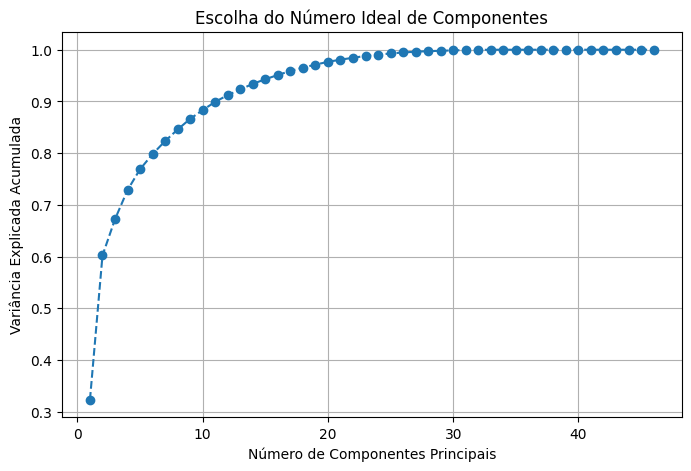

In [22]:
# Fazer scree plot

# Aplicar PCA com todas as dimensões para análise
pca_full = PCA()
pca_full.fit(df_A_scaled)

# Variância explicada acumulada
explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plotar gráfico de variância explicada
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel("Número de Componentes Principais")
plt.ylabel("Variância Explicada Acumulada")
plt.title("Escolha do Número Ideal de Componentes")
plt.grid(True)
plt.show()

In [23]:
parametro_pca = 20

In [24]:
# Aplicar PCA
pca = PCA(n_components=parametro_pca)
principal_components = pca.fit_transform(df_A_scaled)

In [25]:
# Criar um DataFrame com os componentes principais
df_A_pca = pd.DataFrame(principal_components, columns=[f'PC{i+1}' for i in range(parametro_pca)])

df_A_pca.insert(0, "Player", df_A["Player"].values)
df_A_pca.insert(1, "Season", df_A["Season"].values)
df_A_pca.insert(2, "Team", df_A["Team"].values)

In [26]:
# Visualizar a variância explicada
explained_variance = pca.explained_variance_ratio_
total_explained_variance = explained_variance.sum()
print(f"Variância explicada total: {total_explained_variance * 100:.2f}%")

Variância explicada total: 97.66%


In [27]:
df_A_pca

,Player,Season,Team,PC1,PC2,PC3,PC4,PC5,PC6,PC7,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,remo freuler,2018-2019,atalanta,1.578100,10.246378,-1.089524,-2.799955,1.382263,-0.753045,-0.299073,...,0.104796,-0.326805,-1.542348,1.451937,1.526903,1.317702,-0.579423,0.808613,-1.521358,-0.560332
1,marten de roon,2018-2019,atalanta,0.337318,11.584470,-1.365846,-1.061628,2.748380,-0.757582,3.369023,...,0.638152,-0.726402,-0.420218,-0.117183,-0.369933,1.200392,-1.728068,0.444046,-0.662267,-0.646662
2,hans hateboer,2018-2019,atalanta,1.551381,4.470816,2.048481,-3.250691,-0.376419,-0.545868,-2.157068,...,0.820565,0.760643,0.180090,-0.246362,-0.190954,-0.211348,-0.130560,0.734303,-0.183159,-0.816043
3,papu gomez,2018-2019,atalanta,5.225522,3.092084,2.704603,-8.216528,-1.287872,1.188631,-3.700968,...,0.811670,2.378133,0.266646,-2.290178,0.373337,0.547356,-0.966068,0.931326,-1.739292,-0.643446
4,duvan zapata,2018-2019,atalanta,8.127503,0.100901,7.879008,-5.843709,2.131658,-0.517076,-5.558175,...,2.575155,1.007045,1.435553,1.000612,-1.383832,-0.633346,-0.769998,-1.053127,1.659527,-0.798868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2895,nunzio lella,2023-2024,venezia,-0.881554,-3.488396,-1.665269,-0.115369,-0.240307,0.225486,-0.515777,...,-1.345013,0.389054,0.750973,1.031618,-0.063661,0.552293,-0.260769,-0.042006,0.233754,-0.182037
2896,bruno,2023-2024,venezia,-4.373264,-5.099147,0.511512,-1.255224,0.543308,-0.304789,0.792344,...,0.660752,0.387773,-0.141835,-0.130771,-0.265050,0.263463,0.352810,-0.169345,-0.112519,-0.541719
2897,magnus kofod andersen,2023-2024,venezia,-1.688564,-2.910765,-2.361369,0.181944,-0.813259,2.038651,-1.400327,...,0.412582,-1.121351,0.347463,0.589597,-0.141000,0.101793,-0.806655,0.305268,0.195805,0.359775
2898,marco modolo,2023-2024,venezia,-4.562894,-4.260047,0.271051,0.003129,0.545839,1.230137,0.263863,...,1.076838,0.681622,-0.167430,0.301011,0.149765,0.022499,-0.334005,-0.027761,-0.201236,0.326838


# **Carregar dados dos jogos e converter em pontos de cada time por temporada**

In [28]:
# Nome da pasta no GitHub
games_folder = "Games"
base_url = "https://raw.githubusercontent.com/LunusMax/epl-seriea-data/main/Games"
api_url = f"https://api.github.com/repos/LunusMax/epl-seriea-data/contents/{games_folder}"

# Obter todos os arquivos CSV da Serie A
response = requests.get(api_url)
files_json = response.json()
file_A_names = [f["name"] for f in files_json if f["name"].startswith("serie_a") and f["name"].endswith("_resultados.csv")]

# Dicionário com os jogos por temporada
all_seasons_data_A = {}

# Ler cada arquivo e organizar
for file_name in file_A_names:
    season = file_name.split('_')[2].replace('.csv','')
    file_url = f"{base_url}/{file_name}"

    season_data = pd.read_csv(file_url)
    games_list = season_data.to_dict(orient='records')

    for d in games_list:
        d['Em casa'] = d['Em casa'].lower().strip()
        d['Visitante'] = d['Visitante'].lower().strip()

    all_seasons_data_A[season] = games_list

# Mostrar os arquivos carregados em uma linha
print("Arquivos carregados:", file_A_names)

Arquivos carregados: ['serie_a_2018-2019_resultados.csv', 'serie_a_2019-2020_resultados.csv', 'serie_a_2020-2021_resultados.csv', 'serie_a_2021-2022_resultados.csv', 'serie_a_2022-2023_resultados.csv', 'serie_a_2023-2024_resultados.csv']


In [29]:
print(all_seasons_data_A)

{'2018-2019': [{'Em casa': 'chievo', 'Visitante': 'juventus', 'Classe': 2.0}, {'Em casa': 'lazio', 'Visitante': 'napoli', 'Classe': 2.0}, {'Em casa': 'torino', 'Visitante': 'roma', 'Classe': 2.0}, {'Em casa': 'sassuolo', 'Visitante': 'inter', 'Classe': 1.0}, {'Em casa': 'empoli', 'Visitante': 'cagliari', 'Classe': 1.0}, {'Em casa': 'parma', 'Visitante': 'udinese', 'Classe': 0.0}, {'Em casa': 'bologna', 'Visitante': 'spal', 'Classe': 2.0}, {'Em casa': 'atalanta', 'Visitante': 'frosinone', 'Classe': 1.0}, {'Em casa': 'juventus', 'Visitante': 'lazio', 'Classe': 1.0}, {'Em casa': 'napoli', 'Visitante': 'milan', 'Classe': 1.0}, {'Em casa': 'spal', 'Visitante': 'parma', 'Classe': 1.0}, {'Em casa': 'cagliari', 'Visitante': 'sassuolo', 'Classe': 0.0}, {'Em casa': 'genoa', 'Visitante': 'empoli', 'Classe': 1.0}, {'Em casa': 'inter', 'Visitante': 'torino', 'Classe': 0.0}, {'Em casa': 'frosinone', 'Visitante': 'bologna', 'Classe': 0.0}, {'Em casa': 'udinese', 'Visitante': 'sampdoria', 'Classe': 1.

In [30]:
print(f"Temporadas carregadas: {list(all_seasons_data_A.keys())}")

Temporadas carregadas: ['2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024']


In [31]:
# Calcular quantos pontos cada time fez em cada temporada

# Inicializar dicionário para armazenar a pontuação dos times por temporada
team_A_points = {}

# Percorrer cada temporada nos dados carregados
for season, games in all_seasons_data_A.items():
    # Criar um dicionário para armazenar os pontos de cada time nessa temporada
    season_points = {}

    # Percorrer todos os jogos da temporada
    for game in games:
        home_team = game["Em casa"]
        away_team = game["Visitante"]
        match_result = game["Classe"]  # 1.0 = vitória do mandante, 2.0 = vitória do visitante, 0.0 = empate

        # Inicializar os times no dicionário, se ainda não existirem
        if home_team not in season_points:
            season_points[home_team] = 0
        if away_team not in season_points:
            season_points[away_team] = 0

        # Definir a pontuação com base no resultado do jogo
        if match_result == 1.0:
            season_points[home_team] += 3  # Vitória do mandante
        elif match_result == 2.0:
            season_points[away_team] += 3  # Vitória do visitante
        elif match_result == 0.0:
            season_points[home_team] += 1  # Empate
            season_points[away_team] += 1  # Empate

    # Armazenar a pontuação total da temporada
    team_A_points[season] = season_points

# Converter o dicionário para um DataFrame para facilitar a análise
df_A_points = pd.DataFrame([
    {"Season": season, "Team": team, "Points": points}
    for season, teams in team_A_points.items()
    for team, points in teams.items()
])


In [32]:
df_A_points = replace_team_names(df_A_points, team_aliases_A)

In [33]:
# Visualizar as primeiras linhas
df_A_points.head(21)

,Season,Team,Points
0,2018-2019,chievo,20
1,2018-2019,juventus,90
2,2018-2019,lazio,59
3,2018-2019,napoli,79
4,2018-2019,torino,63
5,2018-2019,roma,66
6,2018-2019,sassuolo,43
7,2018-2019,inter,69
8,2018-2019,empoli,38
9,2018-2019,cagliari,41


In [34]:
# Nome da pasta no GitHub
games_folder = "Games"
base_url = "https://raw.githubusercontent.com/LunusMax/epl-seriea-data/main/Games"
api_url = f"https://api.github.com/repos/LunusMax/epl-seriea-data/contents/{games_folder}"

# Obter todos os arquivos CSV da Premier League
response = requests.get(api_url)
files_json = response.json()
file_PL_names = [f["name"] for f in files_json if f["name"].startswith("premier_league") and f["name"].endswith("_resultados.csv")]

# Inicializar dicionário para armazenar as temporadas
all_seasons_data_PL = {}

# Carregar os arquivos e organizar por temporadas
for file_name in file_PL_names:
  # Extrair a temporada do nome do arquivo
  season = file_name.split('_')[2].replace('.csv','')
  file_url = f"{base_url}/{file_name}"
  season_data = pd.read_csv(file_url)

  # Converter DataFrame para lista de dicionários
  games_list = season_data.to_dict(orient='records')

  for d in games_list:
    d['Em casa'] = d['Em casa'].lower().strip()  # remoção de acentos, etc
    d['Visitante'] = d['Visitante'].lower().strip()  # remoção de acentos, etc

  all_seasons_data_PL[season] = games_list

# Mostrar os arquivos carregados em uma linha
print("Arquivos carregados:", file_PL_names)

Arquivos carregados: ['premier_league_2018-2019_resultados.csv', 'premier_league_2019-2020_resultados.csv', 'premier_league_2020-2021_resultados.csv', 'premier_league_2021-2022_resultados.csv', 'premier_league_2022-2023_resultados.csv', 'premier_league_2023-2024_resultados.csv']


In [35]:
# Calcular quantos pontos cada time fez em cada temporada

# Inicializar dicionário para armazenar a pontuação dos times por temporada
team_PL_points = {}

# Percorrer cada temporada nos dados carregados
for season, games in all_seasons_data_PL.items():
    # Criar um dicionário para armazenar os pontos de cada time nessa temporada
    season_points = {}

    # Percorrer todos os jogos da temporada
    for game in games:
        home_team = game["Em casa"]
        away_team = game["Visitante"]
        match_result = game["Classe"]  # 1.0 = vitória do mandante, 2.0 = vitória do visitante, 0.0 = empate

        # Inicializar os times no dicionário, se ainda não existirem
        if home_team not in season_points:
            season_points[home_team] = 0
        if away_team not in season_points:
            season_points[away_team] = 0

        # Definir a pontuação com base no resultado do jogo
        if match_result == 1.0:
            season_points[home_team] += 3  # Vitória do mandante
        elif match_result == 2.0:
            season_points[away_team] += 3  # Vitória do visitante
        elif match_result == 0.0:
            season_points[home_team] += 1  # Empate
            season_points[away_team] += 1  # Empate

    # Armazenar a pontuação total da temporada
    team_PL_points[season] = season_points

df_PL_points = pd.DataFrame([
    {"Season": season, "Team": team, "Points": points}
    for season, teams in team_PL_points.items()
    for team, points in teams.items()
])

In [36]:
df_PL_points = replace_team_names(df_PL_points, team_aliases_PL)

print("\ndf_PL_points after replacement:")
print(df_PL_points.head())


df_PL_points after replacement:
      Season               Team  Points
0  2018-2019  manchester-united      66
1  2018-2019     leicester-city      52
2  2018-2019   newcastle-united      45
3  2018-2019  tottenham-hotspur      71
4  2018-2019             fulham      26


In [37]:
# Visualizar as primeiras linhas
df_PL_points.head(21)

,Season,Team,Points
0,2018-2019,manchester-united,66
1,2018-2019,leicester-city,52
2,2018-2019,newcastle-united,45
3,2018-2019,tottenham-hotspur,71
4,2018-2019,fulham,26
5,2018-2019,crystal-palace,49
6,2018-2019,bournemouth,45
7,2018-2019,cardiff,34
8,2018-2019,huddersfield,16
9,2018-2019,chelsea,72


In [38]:
df_PL_scaled = scaler.transform(df_PL[numeric_columns])
df_PL_pca = pca.transform(df_PL_scaled)

In [39]:
df_PL_pca = pd.DataFrame(df_PL_pca, columns=[f'PC{i+1}' for i in range(parametro_pca)])
df_PL_pca.insert(0, "Player", df_PL["Player"].values)
df_PL_pca.insert(1, "Season", df_PL["Season"].values)
df_PL_pca.insert(2, "Team", df_PL["Team"].values)

In [40]:
# Criar df_Players_pca concatenando df_PL_pca e df_A_pca

df_Players_pca = pd.concat([df_PL_pca, df_A_pca], ignore_index=True)
df_Players_pca.head()

,Player,Season,Team,PC1,PC2,PC3,PC4,PC5,PC6,PC7,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,bernd leno,2018-2019,arsenal,-3.776880,-2.755711,4.389199,-1.349487,-3.725866,-1.545012,3.508453,...,2.428321,1.873335,-0.391360,0.776972,0.020873,0.136732,0.250511,0.078401,0.017215,-0.280377
1,pierre-emerick aubameyang,2018-2019,arsenal,7.630531,0.802123,8.069793,-4.430632,5.423670,0.831943,-2.748804,...,2.003260,-0.091556,-0.276206,2.078868,-1.935186,-0.543595,-1.079261,-0.324580,1.209182,0.020431
2,shkodran mustafi,2018-2019,arsenal,-2.639731,6.937010,1.231397,3.208062,-0.016886,0.548893,-1.049276,...,0.440959,0.213158,0.723764,-0.782570,-0.712518,0.370451,1.123615,0.383083,0.734770,-0.371109
3,granit xhaka,2018-2019,arsenal,-0.632688,6.287923,0.859112,-0.721253,0.071328,-0.397967,1.280710,...,2.135326,1.537310,1.101617,-1.021048,0.478671,0.422863,-1.554932,-0.340029,-0.815409,0.175261
4,alexandre lacazette,2018-2019,arsenal,4.318458,2.012216,3.518578,-4.547409,1.789013,-1.667707,-2.656714,...,2.147947,-0.575890,0.181943,2.340103,-1.238827,0.701480,-0.571674,0.248165,0.732335,-0.056238


# Os dados dos jogadores devem ser os dados da temporada anterior

In [41]:
# Contar o número de jogadores para cada time e temporada combinados no df_PL_pca
player_counts_PL_pca = df_PL_pca.groupby(['Team', 'Season']).size().reset_index(name='player_count')

# Mostrar resultados -> tem que haver 20 jogadores
display(player_counts_PL_pca)

,Team,Season,player_count
0,arsenal,2018-2019,20
1,arsenal,2019-2020,20
2,arsenal,2020-2021,20
3,arsenal,2021-2022,20
4,arsenal,2022-2023,20
...,...,...,...
115,wolverhampton-wanderers,2019-2020,20
116,wolverhampton-wanderers,2020-2021,20
117,wolverhampton-wanderers,2021-2022,20
118,wolverhampton-wanderers,2022-2023,20


In [42]:
# Definir uma função para calcular a temporada anterior
def get_previous_season(season):
    year1, year2 = map(int, season.split('-'))
    return f"{year1 - 1}-{year2 - 1}"

# Listar as colunas do PC
pc_columns = [f"PC{i}" for i in range(1, 21)]

# Fazer o 'shift' das pontuações identificando as colunas
df_PL_pca_shifted = df_PL_pca[['Team', 'Season', 'Player']].copy()

# Adicionar uma coluna temporária para a temporada anterior
df_PL_pca_shifted['prev_season'] = df_PL_pca_shifted['Season'].apply(get_previous_season)

# Juntar as colunas da temporada anterior
df_PL_pca_shifted = df_PL_pca_shifted.merge(
    df_PL_pca[['Team', 'Player', 'Season'] + pc_columns],
    left_on=['Team', 'Player', 'prev_season'],
    right_on=['Team', 'Player', 'Season'],
    how='left'
)

In [43]:
df_PL_pca_shifted

,Team,Season_x,Player,prev_season,Season_y,PC1,PC2,PC3,PC4,PC5,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,arsenal,2018-2019,bernd leno,2017-2018,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,arsenal,2018-2019,pierre-emerick aubameyang,2017-2018,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,arsenal,2018-2019,shkodran mustafi,2017-2018,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,arsenal,2018-2019,granit xhaka,2017-2018,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,arsenal,2018-2019,alexandre lacazette,2017-2018,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2394,wolverhampton-wanderers,2023-2024,santiago bueno,2022-2023,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2395,wolverhampton-wanderers,2023-2024,boubacar traore,2022-2023,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2396,wolverhampton-wanderers,2023-2024,hugo bueno,2022-2023,2022-2023,-2.065643,-0.054811,-1.587104,-1.075917,0.368381,...,-0.232154,-0.031522,-0.864309,-0.362712,-0.514216,-0.594187,0.835884,-0.341715,0.100897,0.330147
2397,wolverhampton-wanderers,2023-2024,daniel bentley,2022-2023,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
# Limpar colunas
df_PL_pca_shifted = df_PL_pca_shifted.drop(columns=['prev_season', 'Season_y'])
df_PL_pca_shifted = df_PL_pca_shifted.rename(columns={'Season_x': 'Season'})

# Preencher valores nulos com 0
df_PL_pca_shifted[pc_columns] = df_PL_pca_shifted[pc_columns].fillna(0)

# Identificar a primeira temporada no df_PL_pca
first_season = df_PL_pca['Season'].min()

# Remover todas as entradas do df_PL_pca_shifter onde a temporada é a primeira
df_PL_pca_shifted = df_PL_pca_shifted[df_PL_pca_shifted['Season'] != first_season]

In [45]:
df_PL_pca_shifted

,Team,Season,Player,PC1,PC2,PC3,PC4,PC5,PC6,PC7,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
20,arsenal,2019-2020,pierre-emerick aubameyang,7.630531,0.802123,8.069793,-4.430632,5.423670,0.831943,-2.748804,...,2.003260,-0.091556,-0.276206,2.078868,-1.935186,-0.543595,-1.079261,-0.324580,1.209182,0.020431
21,arsenal,2019-2020,david luiz,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
22,arsenal,2019-2020,bernd leno,-3.776880,-2.755711,4.389199,-1.349487,-3.725866,-1.545012,3.508453,...,2.428321,1.873335,-0.391360,0.776972,0.020873,0.136732,0.250511,0.078401,0.017215,-0.280377
23,arsenal,2019-2020,granit xhaka,-0.632688,6.287923,0.859112,-0.721253,0.071328,-0.397967,1.280710,...,2.135326,1.537310,1.101617,-1.021048,0.478671,0.422863,-1.554932,-0.340029,-0.815409,0.175261
24,arsenal,2019-2020,nicolas pepe,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2394,wolverhampton-wanderers,2023-2024,santiago bueno,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2395,wolverhampton-wanderers,2023-2024,boubacar traore,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2396,wolverhampton-wanderers,2023-2024,hugo bueno,-2.065643,-0.054811,-1.587104,-1.075917,0.368381,-0.009468,-1.024668,...,-0.232154,-0.031522,-0.864309,-0.362712,-0.514216,-0.594187,0.835884,-0.341715,0.100897,0.330147
2397,wolverhampton-wanderers,2023-2024,daniel bentley,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Data augmentation

In [46]:
# Criar uma cópia das colunas iniciais com valor 0
df_PL_pca_shifted['copy'] = 0

# Listar dfs (original + cópia)
dfs = [df_PL_pca_shifted]

# Criar 10 cópias com colunas sortidas
for i in range(1, 11):
    # Criar cópia do df original
    df_copy = df_PL_pca_shifted.copy()

    df_copy['copy'] = i
    df_copy = df_copy.sample(frac=1, random_state=i).reset_index(drop=True)

    # Adicionar à lista dos dfs
    dfs.append(df_copy)

# Concatenar dataframes
df_PL_augmented = pd.concat(dfs, ignore_index=True)

In [47]:
df_PL_augmented

,Team,Season,Player,PC1,PC2,PC3,PC4,PC5,PC6,PC7,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,copy
0,arsenal,2019-2020,pierre-emerick aubameyang,7.630531,0.802123,8.069793,-4.430632,5.423670,0.831943,-2.748804,...,-0.091556,-0.276206,2.078868,-1.935186,-0.543595,-1.079261,-0.324580,1.209182,0.020431,0
1,arsenal,2019-2020,david luiz,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
2,arsenal,2019-2020,bernd leno,-3.776880,-2.755711,4.389199,-1.349487,-3.725866,-1.545012,3.508453,...,1.873335,-0.391360,0.776972,0.020873,0.136732,0.250511,0.078401,0.017215,-0.280377,0
3,arsenal,2019-2020,granit xhaka,-0.632688,6.287923,0.859112,-0.721253,0.071328,-0.397967,1.280710,...,1.537310,1.101617,-1.021048,0.478671,0.422863,-1.554932,-0.340029,-0.815409,0.175261,0
4,arsenal,2019-2020,nicolas pepe,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21995,newcastle-united,2022-2023,allan saint-maximin,4.847277,-0.534274,1.034358,-2.958883,-2.520225,-0.472294,-1.695183,...,0.875023,0.511340,-1.856615,0.300613,-0.221415,0.777518,0.792549,-0.892358,-0.326233,10
21996,newcastle-united,2020-2021,federico fernandez,-1.359916,4.484043,1.927477,3.406388,-1.667317,0.853485,0.193085,...,0.569315,0.564215,0.900170,-0.116732,-1.380547,1.386030,-1.599179,-0.566137,0.458830,10
21997,chelsea,2020-2021,kurt zouma,-3.277575,2.041289,2.115194,2.221445,-1.371314,0.455083,-0.320035,...,1.316975,0.514200,-0.710032,-0.019240,1.365616,-0.033388,0.995502,0.472214,0.747760,10
21998,manchester-city,2020-2021,riyad mahrez,13.182128,-0.374529,-2.823194,-0.983670,-3.304636,1.845424,-0.033493,...,2.173104,-1.262483,0.786372,0.793358,-0.232162,-0.233492,-0.632888,1.416283,0.012147,10


# Concatena os atributos dos jogadores

In [48]:
try:
    from src.team_season_representation import build_team_season_dataframe
    print("✅ Using PRIVATE team-season representation module")

except ImportError:
    print("⚠️ Using PUBLIC simplified team-season representation module")

    def build_team_season_dataframe(df_augmented, n_components=20):
        """
        Simplified public version.
        Does not reproduce the private augmentation/pivot strategy.
        """

        pc_columns = [col for col in df_augmented.columns if col.startswith("PC")]

        df_team_season = (
            df_augmented[["Season", "Team"] + pc_columns]
            .groupby(["Season", "Team"], as_index=False)
            .mean()
            .fillna(0)
        )

        return df_team_season


df_PL_season = build_team_season_dataframe(df_PL_augmented, n_components=20)

✅ Using PRIVATE team-season representation module


In [49]:
df_PL_season

,Season,Team,copy,PC1_1,PC1_2,PC1_3,PC1_4,PC1_5,PC1_6,PC1_7,...,PC9_11,PC9_12,PC9_13,PC9_14,PC9_15,PC9_16,PC9_17,PC9_18,PC9_19,PC9_20
0,2019-2020,arsenal,0,7.630531,0.000000,-3.776880,-0.632688,0.000000,4.318458,0.000000,...,0.000000,-1.587259,1.572629,-1.964827,0.351727,-1.114226,0.000000,0.000000,0.000000,0.000000
1,2019-2020,arsenal,1,-1.176553,-1.155768,-0.632688,0.000000,7.630531,0.000000,0.000000,...,0.943795,0.000000,2.582003,-1.964827,-2.640615,0.351727,0.000000,-2.066088,0.000000,-1.114226
2,2019-2020,arsenal,2,0.000000,-0.632688,-3.776880,-1.937278,-2.639731,0.000000,0.000000,...,-1.587259,0.000000,0.000000,0.000000,-1.964827,1.572629,2.582003,-1.177416,0.943795,0.000000
3,2019-2020,arsenal,3,-0.632688,0.000000,0.000000,4.318458,0.000000,0.000000,0.000000,...,1.385889,0.351727,0.000000,-1.114226,0.943795,-1.587259,1.572629,-1.964827,0.000000,-2.640615
4,2019-2020,arsenal,4,-1.155768,-1.176553,-2.958525,0.000000,4.318458,-3.776880,-2.213353,...,0.000000,0.351727,-2.066088,-0.339388,0.000000,0.000000,0.000000,1.572629,1.385889,0.943795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,2023-2024,wolverhampton-wanderers,6,0.000000,-2.507020,-1.383901,-0.615588,0.000000,0.000000,-1.300291,...,-3.126125,0.000000,-0.215095,0.376386,-0.885015,-0.519277,-1.119457,0.000000,0.000000,0.000000
1096,2023-2024,wolverhampton-wanderers,7,0.000000,0.000000,-2.065643,0.000000,1.474905,0.000000,-2.094408,...,0.000000,-0.215095,1.020811,-3.126125,0.000000,-0.519277,0.949249,0.000000,-0.799941,0.000000
1097,2023-2024,wolverhampton-wanderers,8,-1.383901,-0.615588,0.000000,-3.933903,0.000000,1.474905,-1.300291,...,0.000000,1.020811,0.000000,-0.215095,-0.519277,0.000000,-1.119457,0.000000,0.000000,0.000000
1098,2023-2024,wolverhampton-wanderers,9,0.000000,0.000000,-3.346466,0.000000,0.000000,0.000000,-1.300291,...,-0.519277,-0.773873,0.000000,0.376386,-1.119457,-3.126125,-0.215095,0.000000,0.058387,0.949249


In [50]:
'''df_PL_model = df_PL_season.merge(
    df_PL_points_shifted[['Team', 'Season', 'Points']],
    on=['Team', 'Season'],
    how='left'
)
'''
df_PL_model = df_PL_season.merge(df_PL_points, on=["Season", "Team"])

df_PL_model

,Season,Team,copy,PC1_1,PC1_2,PC1_3,PC1_4,PC1_5,PC1_6,PC1_7,...,PC9_12,PC9_13,PC9_14,PC9_15,PC9_16,PC9_17,PC9_18,PC9_19,PC9_20,Points
0,2019-2020,arsenal,0,7.630531,0.000000,-3.776880,-0.632688,0.000000,4.318458,0.000000,...,-1.587259,1.572629,-1.964827,0.351727,-1.114226,0.000000,0.000000,0.000000,0.000000,56
1,2019-2020,arsenal,1,-1.176553,-1.155768,-0.632688,0.000000,7.630531,0.000000,0.000000,...,0.000000,2.582003,-1.964827,-2.640615,0.351727,0.000000,-2.066088,0.000000,-1.114226,56
2,2019-2020,arsenal,2,0.000000,-0.632688,-3.776880,-1.937278,-2.639731,0.000000,0.000000,...,0.000000,0.000000,0.000000,-1.964827,1.572629,2.582003,-1.177416,0.943795,0.000000,56
3,2019-2020,arsenal,3,-0.632688,0.000000,0.000000,4.318458,0.000000,0.000000,0.000000,...,0.351727,0.000000,-1.114226,0.943795,-1.587259,1.572629,-1.964827,0.000000,-2.640615,56
4,2019-2020,arsenal,4,-1.155768,-1.176553,-2.958525,0.000000,4.318458,-3.776880,-2.213353,...,0.351727,-2.066088,-0.339388,0.000000,0.000000,0.000000,1.572629,1.385889,0.943795,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,2023-2024,wolverhampton-wanderers,6,0.000000,-2.507020,-1.383901,-0.615588,0.000000,0.000000,-1.300291,...,0.000000,-0.215095,0.376386,-0.885015,-0.519277,-1.119457,0.000000,0.000000,0.000000,46
1096,2023-2024,wolverhampton-wanderers,7,0.000000,0.000000,-2.065643,0.000000,1.474905,0.000000,-2.094408,...,-0.215095,1.020811,-3.126125,0.000000,-0.519277,0.949249,0.000000,-0.799941,0.000000,46
1097,2023-2024,wolverhampton-wanderers,8,-1.383901,-0.615588,0.000000,-3.933903,0.000000,1.474905,-1.300291,...,1.020811,0.000000,-0.215095,-0.519277,0.000000,-1.119457,0.000000,0.000000,0.000000,46
1098,2023-2024,wolverhampton-wanderers,9,0.000000,0.000000,-3.346466,0.000000,0.000000,0.000000,-1.300291,...,-0.773873,0.000000,0.376386,-1.119457,-3.126125,-0.215095,0.000000,0.058387,0.949249,46


In [51]:
df_PL_model = df_PL_model.drop(columns=['copy'], errors='ignore')

# Adiciona pontos da temporada anterior

In [52]:
# Adicionar coluna temporária para temporada anterior
df_PL_model['prev_season'] = df_PL_model['Season'].apply(get_previous_season)

# Buscar pontos da temporada anterior
df_PL_model = df_PL_model.merge(
    df_PL_points[['Team', 'Season', 'Points']].rename(columns={'Points': 'Points_prev'}),
    left_on=['Team', 'prev_season'],
    right_on=['Team', 'Season'],
    how='left'
)

# Limpar colunas e jogar fora desnecessárias
df_PL_model = df_PL_model.drop(columns=['prev_season', 'Season_y'])
df_PL_model = df_PL_model.rename(columns={'Season_x': 'Season'})

df_PL_model = df_PL_model.fillna(0)

In [53]:
df_PL_model

,Season,Team,PC1_1,PC1_2,PC1_3,PC1_4,PC1_5,PC1_6,PC1_7,PC1_8,...,PC9_13,PC9_14,PC9_15,PC9_16,PC9_17,PC9_18,PC9_19,PC9_20,Points,Points_prev
0,2019-2020,arsenal,7.630531,0.000000,-3.776880,-0.632688,0.000000,4.318458,0.000000,-1.937278,...,1.572629,-1.964827,0.351727,-1.114226,0.000000,0.000000,0.000000,0.000000,56,70.0
1,2019-2020,arsenal,-1.176553,-1.155768,-0.632688,0.000000,7.630531,0.000000,0.000000,0.000000,...,2.582003,-1.964827,-2.640615,0.351727,0.000000,-2.066088,0.000000,-1.114226,56,70.0
2,2019-2020,arsenal,0.000000,-0.632688,-3.776880,-1.937278,-2.639731,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.964827,1.572629,2.582003,-1.177416,0.943795,0.000000,56,70.0
3,2019-2020,arsenal,-0.632688,0.000000,0.000000,4.318458,0.000000,0.000000,0.000000,-1.937278,...,0.000000,-1.114226,0.943795,-1.587259,1.572629,-1.964827,0.000000,-2.640615,56,70.0
4,2019-2020,arsenal,-1.155768,-1.176553,-2.958525,0.000000,4.318458,-3.776880,-2.213353,0.000000,...,-2.066088,-0.339388,0.000000,0.000000,0.000000,1.572629,1.385889,0.943795,56,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,2023-2024,wolverhampton-wanderers,0.000000,-2.507020,-1.383901,-0.615588,0.000000,0.000000,-1.300291,-3.346466,...,-0.215095,0.376386,-0.885015,-0.519277,-1.119457,0.000000,0.000000,0.000000,46,41.0
1096,2023-2024,wolverhampton-wanderers,0.000000,0.000000,-2.065643,0.000000,1.474905,0.000000,-2.094408,-0.615588,...,1.020811,-3.126125,0.000000,-0.519277,0.949249,0.000000,-0.799941,0.000000,46,41.0
1097,2023-2024,wolverhampton-wanderers,-1.383901,-0.615588,0.000000,-3.933903,0.000000,1.474905,-1.300291,-2.507020,...,0.000000,-0.215095,-0.519277,0.000000,-1.119457,0.000000,0.000000,0.000000,46,41.0
1098,2023-2024,wolverhampton-wanderers,0.000000,0.000000,-3.346466,0.000000,0.000000,0.000000,-1.300291,0.000000,...,0.000000,0.376386,-1.119457,-3.126125,-0.215095,0.000000,0.058387,0.949249,46,41.0


# Repete tudo para serie A

In [54]:
pc_columns = [f"PC{i}" for i in range(1, 21)]

df_A_pca_shifted = df_A_pca[['Team', 'Season', 'Player']].copy()

df_A_pca_shifted['prev_season'] = df_A_pca_shifted['Season'].apply(get_previous_season)

df_A_pca_shifted = df_A_pca_shifted.merge(
    df_A_pca[['Team', 'Player', 'Season'] + pc_columns],
    left_on=['Team', 'Player', 'prev_season'],
    right_on=['Team', 'Player', 'Season'],
    how='left'
)


df_A_pca_shifted = df_A_pca_shifted.drop(columns=['prev_season', 'Season_y'])
df_A_pca_shifted = df_A_pca_shifted.rename(columns={'Season_x': 'Season'})

df_A_pca_shifted[pc_columns] = df_A_pca_shifted[pc_columns].fillna(0)

first_season = df_A_pca['Season'].min()

df_A_pca_shifted = df_A_pca_shifted[df_A_pca_shifted['Season'] != first_season]

In [55]:
df_A_pca_shifted['copy'] = 0

dfs = [df_A_pca_shifted]

K = 200
for i in range(1, K+1):
    df_copy = df_A_pca_shifted.copy()
    df_copy['copy'] = i
    df_copy = df_copy.sample(frac=1, random_state=i).reset_index(drop=True)
    dfs.append(df_copy)

df_A_augmented = pd.concat(dfs, ignore_index=True)

In [56]:
try:
    from src.team_season_representation import build_team_season_dataframe
    print("✅ Using PRIVATE team-season representation module")

except ImportError:
    print("⚠️ Using PUBLIC simplified team-season representation module")

    def build_team_season_dataframe(df_augmented, n_components=20):
        """
        Public simplified version (no augmentation logic).
        """

        pc_columns = [col for col in df_augmented.columns if col.startswith("PC")]

        df_team_season = (
            df_augmented[["Season", "Team"] + pc_columns]
            .groupby(["Season", "Team"], as_index=False)
            .mean()
            .fillna(0)
        )

        return df_team_season


df_A_season = build_team_season_dataframe(df_A_augmented, n_components=20)

✅ Using PRIVATE team-season representation module


In [57]:
df_A_model = df_A_season.merge(df_A_points, on=["Season", "Team"])
df_A_model = df_A_model.drop(columns=['copy'], errors='ignore')
df_A_model

,Season,Team,PC1_1,PC1_2,PC1_3,PC1_4,PC1_5,PC1_6,PC1_7,PC1_8,...,PC9_12,PC9_13,PC9_14,PC9_15,PC9_16,PC9_17,PC9_18,PC9_19,PC9_20,Points
0,2019-2020,atalanta,-4.156839,5.225522,-2.850111,0.337318,-0.431502,-2.304473,-2.701137,-0.376160,...,0.212488,1.954815,0.000000,0.000000,0.000000,1.473363,0.000000,0.000000,0.000000,78
1,2019-2020,atalanta,-0.431502,-2.701137,0.000000,-2.853196,5.225522,0.337318,1.551381,-0.131294,...,1.275501,2.995566,-0.144737,0.000000,0.720534,0.131155,0.000000,0.000000,0.000000,78
2,2019-2020,atalanta,0.000000,0.000000,-0.431502,-2.701137,1.551381,0.000000,0.337318,-2.850111,...,0.212488,1.473363,2.590021,2.995566,0.000000,1.954815,-0.144737,1.275501,0.000000,78
3,2019-2020,atalanta,-2.701137,0.337318,-2.853196,-0.131294,0.000000,-0.431502,-2.304473,5.225522,...,0.334566,0.720534,2.995566,-1.601149,0.000000,1.275501,1.954815,0.000000,0.000000,78
4,2019-2020,atalanta,0.000000,0.337318,1.551381,0.000000,-0.131294,0.000000,0.000000,8.127503,...,0.000000,0.000000,0.131155,0.508391,2.590021,-1.601149,1.473363,1.954815,1.275501,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20095,2023-2024,udinese,0.000000,0.000000,0.000000,4.490083,0.000000,0.000000,-0.558974,0.000000,...,0.184911,0.651633,0.000000,-0.344881,0.661482,-1.053139,0.000000,-0.589000,-1.374019,37
20096,2023-2024,udinese,5.234738,-2.151481,-1.618371,3.443684,-1.757249,0.000000,-0.629822,4.490083,...,0.000000,0.000000,0.184911,0.000000,0.000000,0.139398,0.000000,0.000000,-0.344881,37
20097,2023-2024,udinese,-0.301699,-0.558974,0.000000,0.000000,2.840186,0.000000,0.000000,0.000000,...,0.661482,0.000000,-0.589000,0.078153,0.000000,-0.344881,1.295116,0.651633,0.000000,37
20098,2023-2024,udinese,2.840186,3.443684,0.000000,0.000000,-0.558974,5.234738,-3.460788,-1.757249,...,0.078153,0.661482,0.184911,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,37


In [58]:
df_A_model['prev_season'] = df_A_model['Season'].apply(get_previous_season)

df_A_model = df_A_model.merge(
    df_A_points[['Team', 'Season', 'Points']].rename(columns={'Points': 'Points_prev'}),
    left_on=['Team', 'prev_season'],
    right_on=['Team', 'Season'],
    how='left'
)

df_A_model = df_A_model.drop(columns=['prev_season', 'Season_y'])
df_A_model = df_A_model.rename(columns={'Season_x': 'Season'})

df_A_model = df_A_model.fillna(0)
df_A_model

,Season,Team,PC1_1,PC1_2,PC1_3,PC1_4,PC1_5,PC1_6,PC1_7,PC1_8,...,PC9_13,PC9_14,PC9_15,PC9_16,PC9_17,PC9_18,PC9_19,PC9_20,Points,Points_prev
0,2019-2020,atalanta,-4.156839,5.225522,-2.850111,0.337318,-0.431502,-2.304473,-2.701137,-0.376160,...,1.954815,0.000000,0.000000,0.000000,1.473363,0.000000,0.000000,0.000000,78,69.0
1,2019-2020,atalanta,-0.431502,-2.701137,0.000000,-2.853196,5.225522,0.337318,1.551381,-0.131294,...,2.995566,-0.144737,0.000000,0.720534,0.131155,0.000000,0.000000,0.000000,78,69.0
2,2019-2020,atalanta,0.000000,0.000000,-0.431502,-2.701137,1.551381,0.000000,0.337318,-2.850111,...,1.473363,2.590021,2.995566,0.000000,1.954815,-0.144737,1.275501,0.000000,78,69.0
3,2019-2020,atalanta,-2.701137,0.337318,-2.853196,-0.131294,0.000000,-0.431502,-2.304473,5.225522,...,0.720534,2.995566,-1.601149,0.000000,1.275501,1.954815,0.000000,0.000000,78,69.0
4,2019-2020,atalanta,0.000000,0.337318,1.551381,0.000000,-0.131294,0.000000,0.000000,8.127503,...,0.000000,0.131155,0.508391,2.590021,-1.601149,1.473363,1.954815,1.275501,78,69.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20095,2023-2024,udinese,0.000000,0.000000,0.000000,4.490083,0.000000,0.000000,-0.558974,0.000000,...,0.651633,0.000000,-0.344881,0.661482,-1.053139,0.000000,-0.589000,-1.374019,37,46.0
20096,2023-2024,udinese,5.234738,-2.151481,-1.618371,3.443684,-1.757249,0.000000,-0.629822,4.490083,...,0.000000,0.184911,0.000000,0.000000,0.139398,0.000000,0.000000,-0.344881,37,46.0
20097,2023-2024,udinese,-0.301699,-0.558974,0.000000,0.000000,2.840186,0.000000,0.000000,0.000000,...,0.000000,-0.589000,0.078153,0.000000,-0.344881,1.295116,0.651633,0.000000,37,46.0
20098,2023-2024,udinese,2.840186,3.443684,0.000000,0.000000,-0.558974,5.234738,-3.460788,-1.757249,...,0.661482,0.184911,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,37,46.0


In [59]:
# Printar valores nulos

# Contar valores nulos para cada coluna
nan_counts_per_row = df_A_model.isnull().sum(axis=1)

print("Number of NaN values in each row:")
nan_counts_per_row.sum()

Number of NaN values in each row:


0

# Treinamento

In [60]:
df_A_model = df_A_model[sorted(df_A_model.columns)]
df_PL_model = df_PL_model[sorted(df_PL_model.columns)]

In [61]:
df_A_model

,PC10_1,PC10_10,PC10_11,PC10_12,PC10_13,PC10_14,PC10_15,PC10_16,PC10_17,PC10_18,...,PC9_4,PC9_5,PC9_6,PC9_7,PC9_8,PC9_9,Points,Points_prev,Season,Team
0,0.382513,-0.242427,-1.179428,0.478614,0.487054,0.000000,0.000000,0.000000,0.252949,0.000000,...,0.194517,0.402847,-0.144737,0.508391,0.131155,0.334566,78,69.0,2019-2020,atalanta
1,1.024578,0.000000,0.487054,-0.242427,-1.179428,0.520475,0.000000,-1.039005,-0.602612,0.000000,...,1.473363,2.590021,0.194517,0.334566,0.212488,-1.601149,78,69.0,2019-2020,atalanta
2,0.000000,0.000000,0.382513,0.478614,0.252949,-0.182832,-1.179428,0.000000,0.487054,0.520475,...,0.508391,0.334566,0.000000,0.194517,0.720534,0.131155,78,69.0,2019-2020,atalanta
3,-0.086048,0.000000,-0.602612,0.396629,-1.039005,-1.179428,0.382513,0.000000,-0.242427,0.487054,...,0.212488,0.000000,0.402847,-0.144737,2.590021,0.000000,78,69.0,2019-2020,atalanta
4,0.000000,-1.039005,1.024578,0.000000,0.000000,-0.602612,-0.086048,-0.182832,0.382513,0.252949,...,0.000000,0.212488,0.000000,0.000000,2.995566,-0.144737,78,69.0,2019-2020,atalanta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20095,0.000000,-0.060447,-0.635556,0.120051,-0.365334,0.000000,2.040044,-1.828288,0.271806,0.000000,...,0.078153,0.000000,0.000000,-0.330558,0.000000,0.000000,37,46.0,2023-2024,udinese
20096,-0.060447,0.000000,0.000000,0.000000,0.000000,0.120051,0.000000,0.000000,-0.635556,0.000000,...,-0.589000,-1.374019,0.000000,0.661482,0.078153,-0.330558,37,46.0,2023-2024,udinese
20097,0.120051,0.271806,0.000000,-1.828288,0.000000,-0.629861,0.248919,0.000000,2.040044,-0.060447,...,0.000000,0.139398,0.000000,0.000000,0.000000,-1.374019,37,46.0,2023-2024,udinese
20098,-0.635556,-0.365334,0.000000,0.248919,-1.828288,0.120051,0.000000,0.000000,0.000000,0.000000,...,0.000000,-0.330558,1.295116,-0.344881,-1.374019,-1.053139,37,46.0,2023-2024,udinese


In [62]:
# Separar features (X) e target (y) para o modelo PL
X_A_train = df_A_model.drop(columns=["Season", "Team", "Points"])  # Features (PC1 a PC10)
y_A_train = df_A_model["Points"]  # Variável alvo (pontuação final)

# Separar features (X) e target (y) para os dados de teste da Serie A
X_PL_test = df_PL_model.drop(columns=["Season", "Team", "Points"])  # Features (PC1 a PC10)
y_PL_test = df_PL_model["Points"]  # Variável alvo (pontuação final)

In [63]:
scaler = StandardScaler()
y_A_train_norm = scaler.fit_transform(y_A_train.values.reshape(-1, 1)).flatten() #PODE SER PROBLEMÁTICO
y_PL_test_norm = scaler.transform(y_PL_test.values.reshape(-1, 1)).flatten()

In [64]:
np.mean(y_A_train_norm), np.std(y_A_train_norm)

(1.0746516998560719e-16, 1.0)

In [65]:
try:
    from src.model import create_model
    print("✅ Using PRIVATE model architecture")

except ImportError:
    print("⚠️ Using PUBLIC simplified model")

    from tensorflow import keras
    from tensorflow.keras import layers

    def create_model(input_dim):
        """
        Simplified public model (does not reflect final architecture)
        """

        model = keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(64, activation='relu'),
            layers.Dense(1)
        ])

        return model

✅ Using PRIVATE model architecture


In [66]:
X_A_train.shape

(20100, 401)

In [67]:
X_PL_test.shape

(1100, 401)

In [68]:
from tensorflow.keras.callbacks import EarlyStopping, Callback
import tensorflow as tf
#from sklearn.metrics import r2_score


model = create_model(X_A_train.shape[1])
model.compile(optimizer='adam', loss='mse', metrics = ['mae', 'mse', tf.keras.metrics.R2Score()])
#model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics = ['mae', 'mse', tf.keras.metrics.R2Score()])


# Callback do Keras que restaura os melhores pesos
early_stop = EarlyStopping(
    monitor='val_r2_score',
    patience=10,
    restore_best_weights=True
)

# Treinamento
history = model.fit(
    X_A_train,
    y_A_train_norm,
    batch_size=32,
    epochs=1000,
    validation_data=(X_PL_test, y_PL_test_norm),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/1000
629/629 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 95.8542 - mae: 1.0574 - mse: 2.0548 - r2_score: -1.0819 - val_loss: 2.2321 - val_mae: 0.6960 - val_mse: 0.7542 - val_r2_score: 0.2135
Epoch 2/1000
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.8809 - mae: 0.5511 - mse: 0.4918 - r2_score: 0.5029 - val_loss: 1.8116 - val_mae: 0.5764 - val_mse: 0.4918 - val_r2_score: 0.4871
Epoch 3/1000
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.7462 - mae: 0.5400 - mse: 0.4665 - r2_score: 0.5285 - val_loss: 1.8167 - val_mae: 0.5987 - val_mse: 0.5465 - val_r2_score: 0.4301
Epoch 4/1000
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.6953 - mae: 0.5438 - mse: 0.4710 - r2_score: 0.5240 - val_loss: 1.8818 - val_mae: 0.6263 - val_mse: 0.6027 - val_r2_score: 0.3716
Epoch 5/1000
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.6605 - mae: 0.5448 - mse: 0.4760 - r2_score: 0.5189 - val_loss: 1.5985 - val_mae: 0.5636 - val_mse: 0.4411 - val_r2_score: 0.5401
Epoch 6/1000
629/629 ━━━━━━

In [69]:
results = model.evaluate(X_PL_test, y_PL_test_norm, verbose=0)
print("Best R2:", results[3])

Best R2: 0.5400703549385071


In [70]:
# =========================
# TEAM REPRESENTATION (PUBLIC INTERFACE)
# =========================

try:
    from src.team_representation import create_team_pca_dataframe
    print("✅ Using PRIVATE team representation module")

except ImportError:
    print("⚠️ Using PUBLIC simplified team representation")

    def create_team_pca_dataframe(team, season, L, player_attributes, player_attributes_PCA, points):
        """
        Simplified public version of team representation.
        Does NOT reflect the full private implementation.
        """

        # Simplified roster selection (no business logic)
        team_players = player_attributes[
            player_attributes['Team'] == team
        ]['Player'].head(20).tolist()

        # Guarantee 20 players
        final_roster = (team_players + L)[:20]

        # Create PCA structure (keeps shape, hides logic)
        pca_columns = [f'PC{i}_{j}' for i in range(1, 21) for j in range(1, 21)]
        result_df = pd.DataFrame(columns=pca_columns, dtype=np.float64)

        for j, player in enumerate(final_roster, 1):

            player_pca = player_attributes_PCA[
                player_attributes_PCA['Player'] == player
            ][[f'PC{i}' for i in range(1, 21)]]

            if player_pca.empty:
                player_data = np.zeros(20)
            else:
                player_data = player_pca.iloc[0].values

            for i, value in enumerate(player_data, 1):
                result_df.loc[0, f'PC{i}_{j}'] = value

        # Simplified points
        result_df['Points_prev'] = 0.0

        return result_df

✅ Using PRIVATE team representation module


In [71]:
try:
    from src.predict import preve_pontos
    print("✅ Using PRIVATE prediction model")

except ImportError:
    print("⚠️ Using PUBLIC simplified prediction")

    def preve_pontos(team, season, new_players, player_attributes, player_attributes_PCA, points,
                     model=None,
                     scaler=None,):
        """
        Simplified public version of prediction function.
        """

        team_df = create_team_pca_dataframe(
            team, season, new_players,
            player_attributes, player_attributes_PCA, points
        )

        # Proxy simples: soma dos PCs
        return float(team_df.sum(axis=1).values[0] * 0.01)


✅ Using PRIVATE prediction model


In [72]:
df_all_players_pca = pd.concat([df_PL_pca, df_A_pca], ignore_index=True)
df_all_players = df_Players

In [73]:
preve_pontos(
    team='cagliari',
    season='2021-2022',
    new_players=[],
    player_attributes=df_all_players,
    player_attributes_PCA=df_all_players_pca,
    points=df_A_points,
    model=model,
    scaler=scaler,
)

41.232155

GERAR A TABELA DE ATRIBUTOS FILTRADOS AQUI

In [74]:
df_player_prev = df_Players[df_Players['Season']=='2020-2021']
df_player_prev_pca = df_Players_pca[df_Players_pca['Season']=='2020-2021']

Guloso First

In [75]:
try:
    from src.optimization import guloso
    print("✅ Using PRIVATE optimization module")

except ImportError:
    print("⚠️ Using PUBLIC simplified optimization module")

    def guloso(
        team,
        season,
        player_attributes,
        player_attributes_PCA,
        points,
        budget,
        predict_function,
        verbose=True,
    ):
        evaluations = 0
        iterations = 0

        price_map = player_attributes.set_index("Player")["Valor_Mercado"].to_dict()
        player_names = player_attributes["Player"].unique().tolist()

        current_new_players = []
        current_score = predict_function(
            team,
            season,
            current_new_players,
            player_attributes,
            player_attributes_PCA,
            points,
        )
        current_cost = 0

        for p in player_names[:10]:
            player_price = price_map.get(p)
            if player_price is None:
                continue

            if current_cost + player_price <= budget:
                current_new_players.append(p)
                current_cost += player_price
                evaluations += 1

        iterations = 1
        return current_new_players, current_cost, current_score, iterations, evaluations

✅ Using PRIVATE optimization module


In [76]:
def preve_pontos_modelo(
    team,
    season,
    new_players,
    player_attributes,
    player_attributes_PCA,
    points,
):
    return preve_pontos(
        team=team,
        season=season,
        new_players=new_players,
        player_attributes=player_attributes,
        player_attributes_PCA=player_attributes_PCA,
        points=points,
        model=model,
        scaler=scaler,
    )

In [77]:
guloso(team='cagliari',
       season='2021-2022',
       player_attributes=df_player_prev,
       player_attributes_PCA=df_player_prev_pca,
       points=df_A_points,
       budget=60000000,
       predict_function=preve_pontos_modelo)

********** New best score: 41.342437744140625
********** New best lineup: ['marten de roon']
********** Added: marten de roon - price: 43766000.0
********** New best score: 41.38163375854492
********** New best lineup: ['marten de roon', 'andres tello']
********** Added: andres tello - price: 13267900.000000002
********** New best score: 41.524192810058594
********** New best lineup: ['marten de roon', 'andres tello', 'kiko casilla']
********** Added: kiko casilla - price: 2790000.0


(['marten de roon', 'andres tello', 'kiko casilla'],
 59823900.0,
 41.524193,
 4,
 9)

In [78]:
try:
    from src.optimization import guloso_best
    print("✅ Using PRIVATE greedy best module")

except ImportError:
    print("⚠️ Using PUBLIC simplified greedy best module")

    def guloso_best(
        team,
        season,
        player_attributes,
        player_attributes_PCA,
        points,
        budget,
        predict_function,
        verbose=True,
        progress=True,
    ):
        evaluations = 0
        iterations = 1

        price_map = player_attributes.set_index("Player")["Valor_Mercado"].to_dict()
        player_names = player_attributes["Player"].unique().tolist()

        current_new_players = []
        current_score = predict_function(
            team,
            season,
            current_new_players,
            player_attributes,
            player_attributes_PCA,
            points,
        )
        current_cost = 0

        for p in player_names[:10]:
            player_price = price_map.get(p)

            if player_price is None:
                continue

            if p not in current_new_players and current_cost + player_price <= budget:
                current_new_players.append(p)
                current_cost += player_price
                evaluations += 1

        return current_new_players, current_cost, current_score, iterations, evaluations

✅ Using PRIVATE greedy best module


In [79]:
try:
    from src.optimization import busca_local
    print("✅ Using PRIVATE local search module")

except ImportError:
    print("⚠️ Using PUBLIC simplified local search module")

    def busca_local(
        team,
        season,
        player_attributes,
        player_attributes_PCA,
        points,
        budget,
        predict_function,
        verbose=True,
    ):
        evaluations = 0
        iterations = 1
        improvements = 0

        current_new_players, current_cost, current_score, _, _ = guloso(
            team=team,
            season=season,
            player_attributes=player_attributes,
            player_attributes_PCA=player_attributes_PCA,
            points=points,
            budget=budget,
            predict_function=predict_function,
            verbose=verbose,
        )

        return current_new_players, current_cost, current_score, iterations, evaluations, improvements

✅ Using PRIVATE local search module


In [80]:
try:
    from src.optimization import busca_local_best
    print("✅ Using PRIVATE local search best module")

except ImportError:
    print("⚠️ Using PUBLIC simplified local search best module")

    def busca_local_best(
        team,
        season,
        player_attributes,
        player_attributes_PCA,
        points,
        budget,
        predict_function,
        verbose=True,
        log_interval=5000,
    ):
        evaluations = 0
        iterations = 1
        improvements = 0

        current_new_players, current_cost, current_score, _, _ = guloso(
            team=team,
            season=season,
            player_attributes=player_attributes,
            player_attributes_PCA=player_attributes_PCA,
            points=points,
            budget=budget,
            predict_function=predict_function,
            verbose=verbose,
        )

        return current_new_players, current_cost, current_score, iterations, evaluations, improvements

✅ Using PRIVATE local search best module


# Benchmarking

In [81]:
import time

def medir_tempo(func, **kwargs):
    start = time.perf_counter()
    result = func(**kwargs)
    end = time.perf_counter()
    runtime = end - start
    return result, runtime

In [82]:
def extrair_metricas(res):
    return {
        "Score": res[2] if len(res) > 2 else None,
        "Iteracoes": res[3] if len(res) > 3 else None,
        "Avaliacoes": res[4] if len(res) > 4 else None,
        "Melhoras": res[5] if len(res) > 5 else None,
    }

In [83]:
SEED = 532
random.seed(SEED)

algoritmos = {
    "Guloso First": lambda: guloso(
        team='cagliari',
        season='2021-2022',
        player_attributes=df_player_prev,
        player_attributes_PCA=df_player_prev_pca,
        points=df_A_points,
        budget=60000000,
        predict_function=preve_pontos_modelo
    ),

    "Guloso Best": lambda: guloso_best(
        team='cagliari',
        season='2021-2022',
        player_attributes=df_player_prev,
        player_attributes_PCA=df_player_prev_pca,
        points=df_A_points,
        budget=60000000,
        predict_function=preve_pontos_modelo
    ),

    "Local First": lambda: busca_local(
        team='cagliari',
        season='2021-2022',
        player_attributes=df_player_prev,
        player_attributes_PCA=df_player_prev_pca,
        points=df_A_points,
        budget=60000000,
        predict_function=preve_pontos_modelo
    ),

    "Local Best": lambda: busca_local_best(
        team='cagliari',
        season='2021-2022',
        player_attributes=df_player_prev,
        player_attributes_PCA=df_player_prev_pca,
        points=df_A_points,
        budget=60000000,
        predict_function=preve_pontos_modelo
    ),
}

In [85]:
registros = []

for nome, chamada in algoritmos.items():
    res, tempo = medir_tempo(chamada)
    m = extrair_metricas(res)

    registros.append({
        "Algoritmo": nome,
        "Tempo (s)": tempo,
        "Iterações": m["Iteracoes"],
        "Avaliações": m["Avaliacoes"],
        "Melhoras": m["Melhoras"],
        "Score final": m["Score"]
    })

df_benchmark_1x = pd.DataFrame(registros)
print(df_benchmark_1x)

********** New best score: 41.342437744140625
********** New best lineup: ['marten de roon']
********** Added: marten de roon - price: 43766000.0
********** New best score: 41.38163375854492
********** New best lineup: ['marten de roon', 'andres tello']
********** Added: andres tello - price: 13267900.000000002
********** New best score: 41.524192810058594
********** New best lineup: ['marten de roon', 'andres tello', 'kiko casilla']
********** Added: kiko casilla - price: 2790000.0
marten de roon 41.342438 0.0
remo freuler 41.168747 0.0010672358591248667
berat djimsiti 41.13844 0.0021344717182497333
cristian romero 41.23552 0.0032017075773745998
rafael toloi 41.137207 0.004268943436499467
robin gosens 40.67001 0.005336179295624333
jose luis palomino 41.27274 0.0064034151547491995
duvan zapata 40.259094 0.007470651013874066
pierluigi gollini 41.199554 0.008537886872998933
ruslan malinovskyi 40.446133 0.0096051227321238
hans hateboer 41.037807 0.010672358591248666
matteo pessina 41.0082

TypeError: busca_local() missing 1 required positional argument: 'greedy_function'

In [ ]:
SEED = 532
random.seed(SEED)

algoritmos = {
    "Guloso First": lambda: guloso(
        team='napoli',
        season='2021-2022',
        player_attributes=df_player_prev,
        player_attributes_PCA=df_player_prev_pca,
        points=df_A_points,
        budget=120000000,
        predict_function=preve_pontos_modelo
    ),

    "Guloso Best": lambda: guloso_best(
        team='napoli',
        season='2021-2022',
        player_attributes=df_player_prev,
        player_attributes_PCA=df_player_prev_pca,
        points=df_A_points,
        budget=120000000,
        predict_function=preve_pontos_modelo
    ),

    "Local First": lambda: busca_local(
        team='napoli',
        season='2021-2022',
        player_attributes=df_player_prev,
        player_attributes_PCA=df_player_prev_pca,
        points=df_A_points,
        budget=120000000,
        predict_function=preve_pontos_modelo
    ),

    "Local Best": lambda: busca_local_best(
        team='napoli',
        season='2021-2022',
        player_attributes=df_player_prev,
        player_attributes_PCA=df_player_prev_pca,
        points=df_A_points,
        budget=120000000,
        predict_function=preve_pontos_modelo
    ),
}

In [ ]:
SEED_BASE = 532
n = 3

registros_n = []

for rodada in range(1, n + 1):
    random.seed(SEED_BASE + rodada)

    for nome, chamada in algoritmos.items():
        res, tempo = medir_tempo(chamada)
        m = extrair_metricas(res)

        registros_n.append({
            "Rodada": rodada,
            "Algoritmo": nome,
            "Tempo": tempo,
            "Iteracoes": m["Iteracoes"],
            "Avaliacoes": m["Avaliacoes"],
            "Melhoras": m["Melhoras"],
            "Score": m["Score"]
        })

df_benchmark_n = pd.DataFrame(registros_n)
print(df_benchmark_n)

In [ ]:
preve_pontos(team='cagliari',
             season='2021-2022',
             new_players=[],
             player_attributes=df_all_players,
             player_attributes_PCA=df_all_players_pca,
             points=df_A_points,
            )

In [ ]:
preve_pontos(team='napoli',
             season='2021-2022',
             new_players=[],
             player_attributes=df_all_players,
             player_attributes_PCA=df_all_players_pca,
             points=df_A_points,
            )

In [ ]:
for rodada in range(1, n + 1):
    for nome, chamada in algoritmos.items():
        random.seed(SEED_BASE + rodada)

        res, tempo = medir_tempo(chamada)
        m = extrair_metricas(res)

        registros_n.append({
            "Rodada": rodada,
            "Algoritmo": nome,
            "Tempo": tempo,
            "Iteracoes": m["Iteracoes"],
            "Avaliacoes": m["Avaliacoes"],
            "Melhoras": m["Melhoras"],
            "Score": m["Score"]
        })

df_benchmark_n = pd.DataFrame(registros_n)
print(df_benchmark_n)